# Notebook 03: Exploratory Data Analysis

## Objective

This notebook explores the wide receiver dataset created in Notebook 02. The goal is to understand the data before feature engineering and modeling.

The analysis focuses on missing values, distributions, outliers, correlations, and the relationship between current and next season receiving yards.

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from pathlib import Path

data_path = Path("../data/processed/wr_master.csv")

wr_master = pl.read_csv(data_path)

print("Dataset loaded successfully!")
print(f"Shape: {wr_master.shape}")

Dataset loaded successfully!
Shape: (3151, 186)


## Dataset Overview

The dataset contains one observation for each wide receiver and season. Before selecting variables for detailed analysis, the dataset structure, data types, and missing values are examined to verify that the imported data are consistent with expectations.

### Table 1. Dataset Data-Type Summary

Numeric variables represent player performance, usage, and physical characteristics, while string variables primarily contain identifiers and descriptive metadata.

In [3]:
# Count columns by data type
dtype_counts = (
    pl.DataFrame(
        {
            "Data Type": [str(dtype) for dtype in wr_master.dtypes]
        }
    )
    .group_by("Data Type")
    .len()
    .rename({"len": "Count"})
    .sort("Count", descending=True)
)

dtype_counts

Data Type,Count
str,u32
"""Int64""",132
"""String""",41
"""Float64""",13


### Interpretation

Most variables are numeric, including 127 integer variables and 13 floating-point variables. The 41 string variables largely represent player identifiers, team information, positions, and external database references. 

### Table 2. Variables With Substantial Missingness

Variables containing at least 10% missing values are examined to distinguish genuine data quality concerns from fields that are inapplicable to wide receivers. Missing values are documented during EDA but are not imputed or removed at this stage.

In [4]:
# Calculate missing values for each variable
missing_summary = (
    wr_master.null_count()
    .transpose(
        include_header=True,
        header_name="Variable",
        column_names=["Missing Values"]
    )
    .filter(pl.col("Missing Values") > 0)
    .with_columns(
        (
            pl.col("Missing Values") / wr_master.height * 100
        )
        .round(2)
        .alias("Percent Missing")
    )
    .sort("Percent Missing", descending=True)
)

# Retain variables with at least 10% missing values
high_missing_summary = (
    missing_summary
    .filter(pl.col("Percent Missing") >= 10)
)

high_missing_summary

Variable,Missing Values,Percent Missing
str,u32,f64
"""fg_long""",3151,100.0
"""fg_pct""",3151,100.0
"""fg_made_list""",3151,100.0
"""fg_missed_list""",3151,100.0
"""fg_blocked_list""",3151,100.0
…,…,…
"""draft_pick""",1006,31.93
"""draft_team""",1006,31.93
"""college_conference""",767,24.34


### Interpretation

Several kicking related variables are entirely missing because they are not applicable to wide receivers. These columns remain from the broader player statistics source and will be excluded during feature engineering.

Draft round and draft pick are missing for approximately 32% of observations, largely because undrafted players do not have draft values. College conference and selected player metadata also contain moderate missingness. These patterns require feature-specific treatment rather than blanket row deletion.

## Variables for Exploratory Analysis

The full dataset contains many position specific and administrative variables that are not directly relevant to predicting wide receiver performance. A focused subset was selected to represent player characteristics, offensive opportunity, receiving production, efficiency, ball security, and fantasy production.

Player identifiers and team information are retained for context but will not automatically be used as model predictors.

In [5]:
eda_columns = [
    "player_id",
    "player_name",
    "season",
    "recent_team",
    "height",
    "weight",
    "years_of_experience",
    "draft_round",
    "draft_pick",
    "games",
    "targets",
    "target_share",
    "air_yards_share",
    "receptions",
    "receiving_yards",
    "receiving_tds",
    "receiving_air_yards",
    "receiving_yards_after_catch",
    "receiving_first_downs",
    "receiving_epa",
    "racr",
    "wopr",
    "receiving_fumbles",
    "receiving_fumbles_lost",
    "fantasy_points",
    "fantasy_points_ppr",
]

eda_df = wr_master.select(eda_columns)

print(f"EDA dataset shape: {eda_df.shape}")


EDA dataset shape: (3151, 26)


## Descriptive Statistics

### Table 3. Descriptive Statistics for Candidate Numerical Variables

The table reports the number of valid observations, missing values, mean, standard deviation, minimum, quartiles, median, and maximum for each selected numerical variable. These statistics summarize the scale, variability, and distribution of the candidate predictors before preprocessing.

In [6]:
# Select only numeric variables
numeric_df = eda_df.select(pl.selectors.numeric())

# Build one row per numeric variable
summary_rows = []

for col in numeric_df.columns:
    series = numeric_df[col]

    summary_rows.append({
        "Variable": col,
        "Count": series.len() - series.null_count(),
        "Missing": series.null_count(),
        "Mean": float(series.mean()) if series.mean() is not None else None,
        "Std Dev": float(series.std()) if series.std() is not None else None,
        "Min": float(series.min()) if series.min() is not None else None,
        "Q1": float(series.quantile(0.25)) if series.quantile(0.25) is not None else None,
        "Median": float(series.median()) if series.median() is not None else None,
        "Q3": float(series.quantile(0.75)) if series.quantile(0.75) is not None else None,
        "Max": float(series.max()) if series.max() is not None else None,
    })

summary_table = (
    pl.DataFrame(summary_rows)
    .with_columns(
        pl.col("Count").cast(pl.Int64),
        pl.col("Missing").cast(pl.Int64),
        pl.col("Mean", "Std Dev", "Min", "Q1", "Median", "Q3", "Max")
        .cast(pl.Float64)
        .round(2)
    )
)

summary_table

Variable,Count,Missing,Mean,Std Dev,Min,Q1,Median,Q3,Max
str,i64,i64,f64,f64,f64,f64,f64,f64,f64
"""season""",3151,0,2018.71,4.02,2012.0,2015.0,2019.0,2022.0,2025.0
"""height""",3151,0,72.51,2.41,65.0,71.0,73.0,74.0,78.0
"""weight""",3151,0,200.28,15.31,153.0,190.0,200.0,211.0,245.0
"""years_of_experience""",3151,0,6.58,3.37,0.0,4.0,6.0,9.0,17.0
"""draft_round""",2145,1006,3.34,1.9,1.0,2.0,3.0,5.0,7.0
…,…,…,…,…,…,…,…,…,…
"""wopr""",3151,0,0.2,0.2,0.0,0.03,0.14,0.33,0.95
"""receiving_fumbles""",3151,0,0.29,0.61,0.0,0.0,0.0,0.0,4.0
"""receiving_fumbles_lost""",3151,0,0.16,0.42,0.0,0.0,0.0,0.0,3.0


### Interpretation

The descriptive statistics reveal substantial variation in wide receiver usage and production. Receiving yards have a median of 216 but a mean of approximately 361, indicating a right-skewed distribution influenced by a smaller number of high-production seasons.

Targets, receptions, receiving air yards, yards after catch, and fantasy points show similar differences between their medians and means. Draft round and draft pick contain 1,006 missing observations, while receiving EPA and RACR contain smaller amounts of missing data.

Negative minimum values for receiving yards, air yards, yards after catch, and EPA are possible because individual plays may produce losses. These values are not automatically treated as errors.

## Figure 1. Distribution of Receiving Yards

### Purpose

This figure examines the distribution of current season receiving yards across wide receiver player seasons. Understanding the response variable's shape helps identify skewness, concentration, and extreme observations that may affect later preprocessing and model selection.

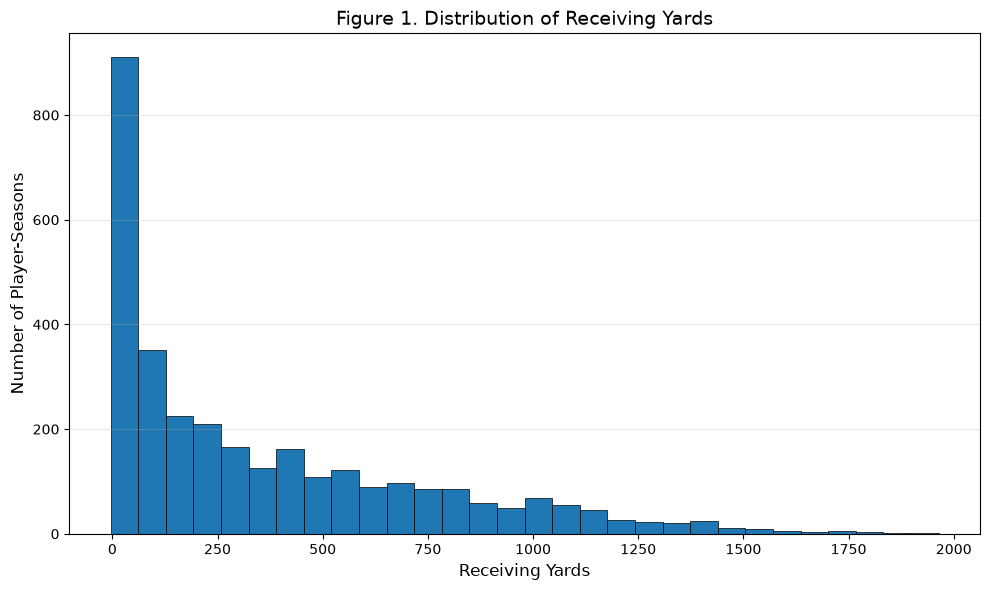

In [7]:
plt.figure(figsize=(10, 6))

plt.hist(
    eda_df["receiving_yards"],
    bins=30,
    edgecolor="black",
    linewidth=0.5
)

plt.title("Figure 1. Distribution of Receiving Yards", fontsize=14)
plt.xlabel("Receiving Yards", fontsize=12)
plt.ylabel("Number of Player-Seasons", fontsize=12)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

Receiving yards are strongly right skewed. Most wide receiver player seasons fall toward the lower end of the distribution, while a much smaller number exceed 1,000 yards. The long right tail represents high volume and elite receiving seasons rather than an obvious data quality problem.

## Figure 2. Targets and Receiving Yards

### Purpose

This figure examines the relationship between receiving opportunities and receiving production. Targets represent how often a player is selected as the intended receiver, while receiving yards measure the resulting production.

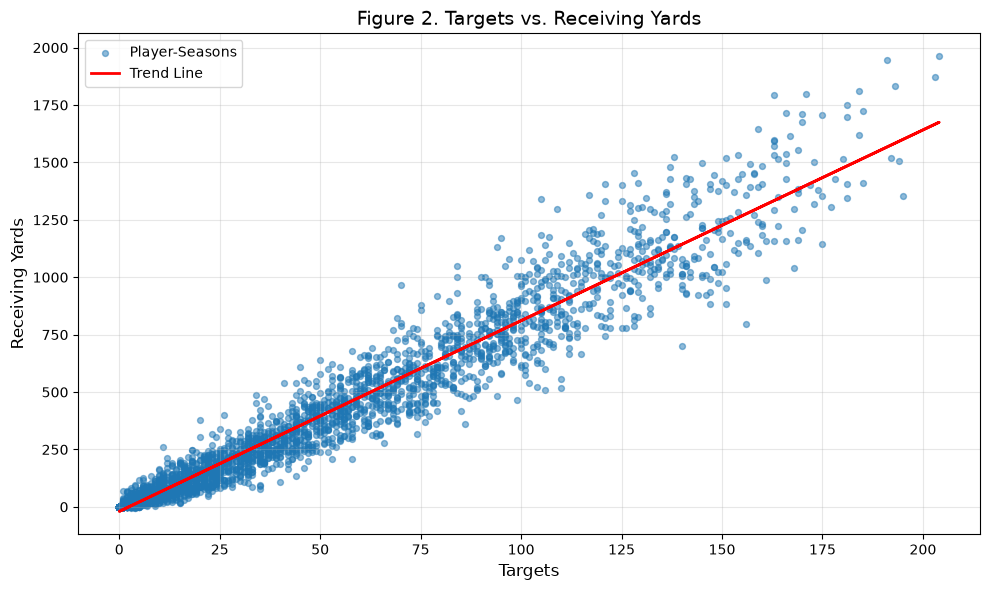

In [8]:
# Calculate regression line
m, b = np.polyfit(
    eda_df["targets"],
    eda_df["receiving_yards"],
    1
)

plt.figure(figsize=(10, 6))

plt.scatter(
    eda_df["targets"],
    eda_df["receiving_yards"],
    alpha=0.5,
    s=18,
    label="Player-Seasons"
)

plt.plot(
    eda_df["targets"],
    m * eda_df["targets"] + b,
    color="red",
    linewidth=2,
    label="Trend Line"
)

plt.title("Figure 2. Targets vs. Receiving Yards", fontsize=14)
plt.xlabel("Targets", fontsize=12)
plt.ylabel("Receiving Yards", fontsize=12)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Interpretation

Targets and receiving yards display a strong, approximately linear positive relationship. Players receiving more targets generally accumulate more receiving yards. The vertical spread grows at higher target totals, indicating that receivers with similar opportunity levels can still differ meaningfully in efficiency and production.

## Figure 3. Correlation Matrix of Candidate Predictor Variables

### Purpose

Correlation analysis measures the strength and direction of linear relationships among the selected numerical variables. The analysis helps identify variables strongly associated with receiving yards and potential multicollinearity among predictors.

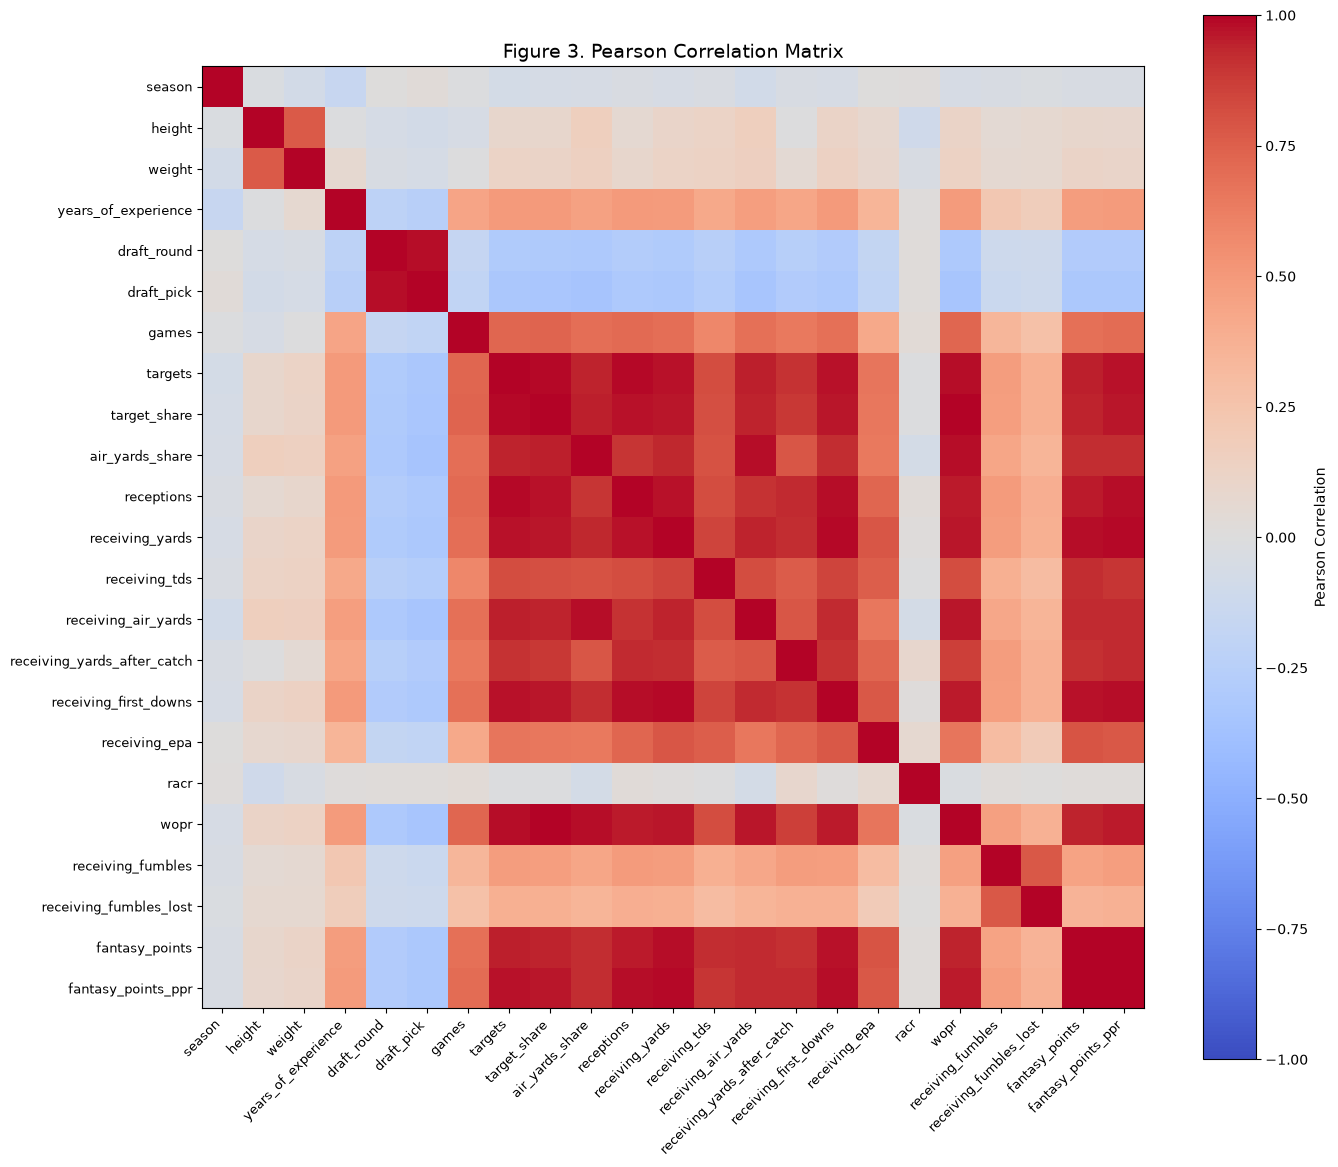

In [9]:
corr_df = (
    numeric_df
    .fill_nan(None)
    .fill_null(strategy="mean")
)

corr_matrix = corr_df.corr()
corr = corr_matrix.to_numpy()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(
    corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(
    corr_matrix.columns,
    rotation=45,
    ha="right",
    fontsize=9
)

ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_yticklabels(
    corr_matrix.columns,
    fontsize=9
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Pearson Correlation")

ax.set_title("Figure 3. Pearson Correlation Matrix", fontsize=14)

plt.tight_layout()
plt.show()

### Interpretation

The heatmap reveals a large cluster of strongly correlated receiving production variables. Targets, receptions, receiving first downs, receiving air yards, target share, WOPR, and fantasy scoring measures move closely with receiving yards and with one another.

## Table 4. Variables Most Strongly Correlated With Receiving Yards

The table provides exact Pearson correlation coefficients for the ten variables most strongly associated with current-season receiving yards. It complements Figure 3 by reporting precise values rather than requiring visual estimation.

In [10]:
receiving_corr = (
    pl.DataFrame({
        "Variable": corr_matrix.columns,
        "Correlation": corr_matrix["receiving_yards"]
    })
    .filter(pl.col("Variable") != "receiving_yards")
    .sort("Correlation", descending=True)
    .with_columns(
        pl.col("Correlation").round(3)
    )
)

receiving_corr.head(10)

Variable,Correlation
str,f64
"""fantasy_points_ppr""",0.988
"""receiving_first_downs""",0.985
"""fantasy_points""",0.981
"""receptions""",0.972
"""targets""",0.972
"""wopr""",0.964
"""target_share""",0.963
"""receiving_air_yards""",0.944
"""air_yards_share""",0.936


### Interpretation

Fantasy points PPR, receiving first downs, fantasy points, receptions, and targets have the strongest correlations with receiving yards. WOPR, target share, receiving air yards, air yards share, and yards after catch are also strongly associated with production.

These results confirm that opportunity and receiving volume dominate current season production. They also reinforce the need to control redundancy during feature selection.

## Figure 4. Distribution and Outliers of Key Performance Variables

### Purpose

Boxplots are used to examine the medians, interquartile ranges, overall spread, and potential outliers in receiving yards, targets, and fantasy points. In professional sports data, extreme observations may represent legitimate elite performances rather than errors.

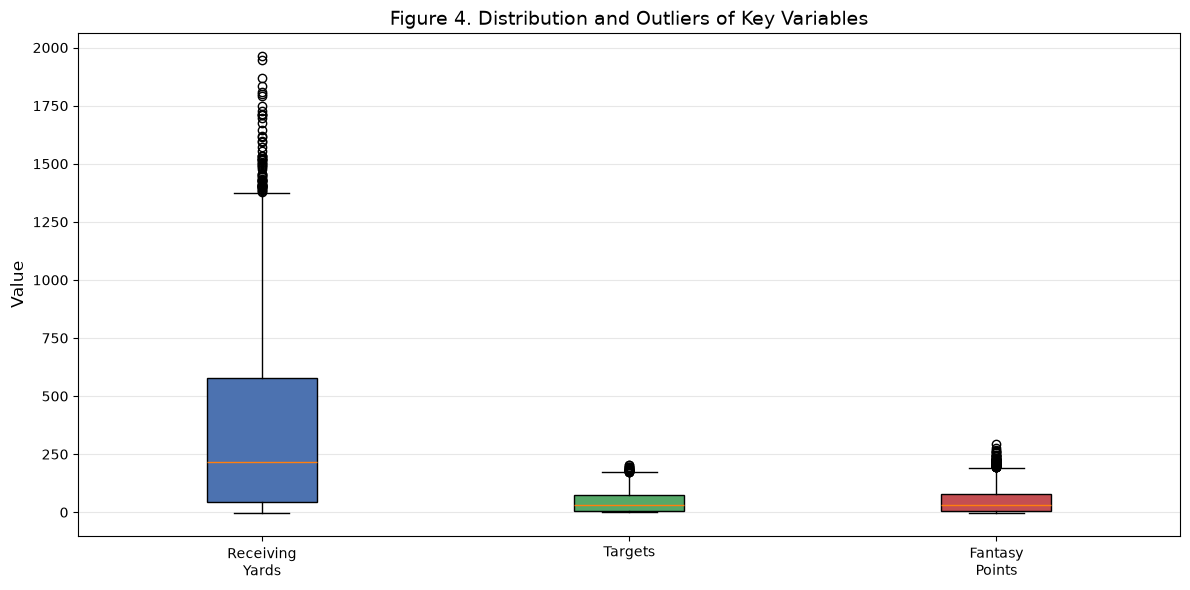

In [11]:
boxplot_vars = [
    "receiving_yards",
    "targets",
    "fantasy_points"
]

plt.figure(figsize=(12, 6))

box = plt.boxplot(
    [eda_df[col].to_list() for col in boxplot_vars],
    tick_labels=[
        "Receiving\nYards",
        "Targets",
        "Fantasy\nPoints"
    ],
    patch_artist=True
)

colors = ["#4C72B0", "#55A868", "#C44E52"]

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)

plt.title(
    "Figure 4. Distribution and Outliers of Key Variables",
    fontsize=14
)
plt.ylabel("Value", fontsize=12)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

Receiving yards show the widest distribution and the largest number of high end outliers. Targets and fantasy points also contain observations beyond their upper whiskers, although their numerical scales are smaller.

## Figure 5. Previous-Season vs. Next Season Receiving Yards

### Purpose

This scatterplot examines the relationship between a wide receiver's receiving yards in one season and their receiving yards during the following season.

In [12]:
model_df = pl.read_csv("../data/processed/wr_model.csv")

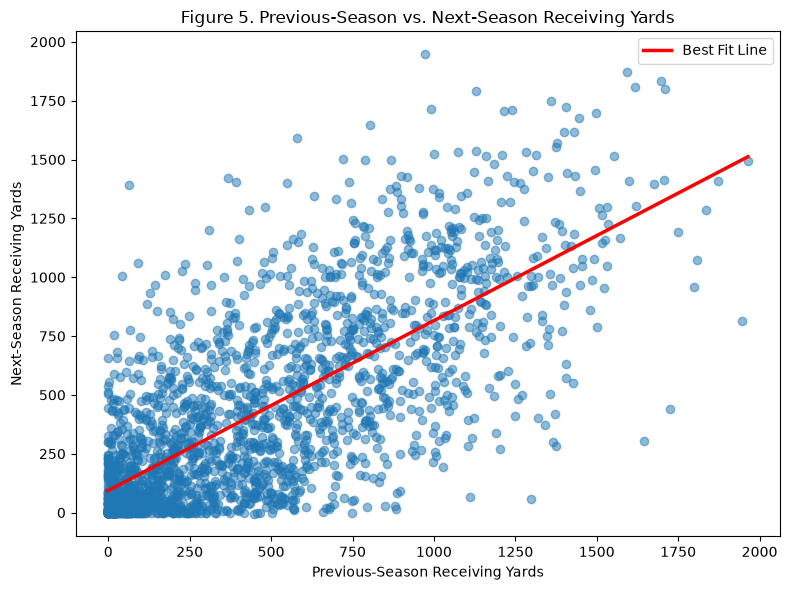

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Create plotting dataset

plot_df = (
    model_df
    .select([
        "receiving_yards",
        "next_season_receiving_yards"
    ])
    .drop_nulls()
)

x = plot_df["receiving_yards"].to_numpy()
y = plot_df["next_season_receiving_yards"].to_numpy()

# Fit regression line
slope, intercept = np.polyfit(x, y, 1)

plt.figure(figsize=(8,6))

plt.scatter(
    x,
    y,
    alpha=0.5
)

plt.plot(
    np.sort(x),
    slope * np.sort(x) + intercept,
    color="red",
    linewidth=2.5,
    label="Best Fit Line"
)

plt.legend()

plt.title("Figure 5. Previous-Season vs. Next-Season Receiving Yards")
plt.xlabel("Previous-Season Receiving Yards")
plt.ylabel("Next-Season Receiving Yards")

plt.tight_layout()
plt.show()

### Interpretation

Wide receivers with higher receiving yardage in one season generally tend to produce more receiving yards in the following season. However, the spread around the regression line indicates substantial variation, suggesting that future performance is also influenced by other factors such as age, injuries, offensive scheme, quarterback play, and target volume.

# Notebook 03 Summary

The EDA found that the wide receiver dataset contains 3,151 player season observations and 186 variables. Most missing values have reasonable explanations. Kicking statistics do not apply to wide receivers, while draft information is missing for many undrafted players.

Receiving yards are right skewed, with many lower production seasons and a smaller number of high production seasons. Targets, receptions, receiving first downs, receiving air yards, target share, WOPR, and fantasy measures are strongly related to receiving yards. Many of these variables are also highly correlated with one another, so redundancy will need to be addressed before modeling.

Previous season receiving yards are related to next season receiving yards, but there is substantial variation between seasons. Historical production alone is therefore not enough to explain future performance.

The dataset does not include every factor that can affect a receiver's production. Injuries, quarterback changes, coaching, offensive scheme, and other roster factors may influence future receiving yards but are not directly represented in the available data.

The next step is feature engineering and preparation of the modeling dataset.

In [14]:
model_df = pl.read_csv("../data/processed/wr_model.csv")

In [15]:
for col in model_df.columns:
    if "receiv" in col.lower() or "target" in col.lower() or "next" in col.lower():
        print(col)

targets
receiving_yards
receiving_tds
receiving_fumbles
receiving_fumbles_lost
receiving_air_yards
receiving_yards_after_catch
receiving_first_downs
receiving_epa
receiving_2pt_conversions
receiving_10
receiving_16
receiving_20
receiving_40
target_share
next_season_receiving_yards
yards_per_target
